In [1]:
import numpy as np
from pathlib import Path
import pickle
import torch
import torch.nn as nn

In [4]:
from pathlib import Path
PROJECT_ROOT = Path.home() / 'Desktop' / 'ml'
DATA_DIR = PROJECT_ROOT / 'sp2' / 'data' / 'processed'
CHECKPOINT_DIR = PROJECT_ROOT / "sp2" / "checkpoints"

loaded_data = np.load(DATA_DIR / 'test_dataset.npz')
print(f"Arrays found in npz file: {list(loaded_data.keys())}")

if len(loaded_data.keys()) > 0:
    first_key = list(loaded_data.keys())[0]
    print(f"First array '{first_key}' shape: {loaded_data[first_key].shape}")
else:
    print("No arrays found in the .npz file.")

Arrays found in npz file: ['song_id', 'time', 'valence', 'arousal', 'valence_std', 'arousal_std']
First array 'song_id' shape: (13984,)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from typing import Tuple, List, Dict
import json

class EmotionTagger:

    def __init__(self, thresholds=None):
        if thresholds is None:
            # Simplified thresholds, as valence/arousal now use 0 as the division line
            thresholds = {
                'neutral_radius': 0.1 # Using the value from XUDRSho1rDqy which seems reasonable for a neutral zone.
            }
        self.thresholds = thresholds

        # 5 emotions (4 quadranty + neutral)
        self.emotion_labels = ['NEUTRAL', 'HAPPY', 'CALM', 'ANGRY', 'SAD']

        # Mapping dla każdej emocji
        self.emotion_colors = {
            'NEUTRAL': '#808080',  # Gray
            'HAPPY': '#FFD700',    # Gold
            'CALM': '#87CEEB',     # Sky blue
            'ANGRY': '#FF6347',    # Tomato red
            'SAD': '#4169E1'       # Royal blue
        }

    def tag_emotion(self, valence: float, arousal: float) -> str:
        neutral_r = self.thresholds['neutral_radius']

        # Neutral zone around (0,0)
        dist = np.sqrt(valence**2 + arousal**2)
        if dist < neutral_r:
            return 'NEUTRAL'

        # Quadrant classification using raw valence and arousal
        if valence >= 0 and arousal >= 0:
            return 'HAPPY'        # Positive + Active
        elif valence >= 0 and arousal < 0:
            return 'CALM'         # Positive + Passive
        elif valence < 0 and arousal >= 0:
            return 'ANGRY'        # Negative + Active
        else: # valence < 0 and arousal < 0
            return 'SAD'          # Negative + Passive

    def tag_batch(self, valences: np.ndarray, arousals: np.ndarray) -> np.ndarray:
        emotions = np.array([
            self.tag_emotion(v, a)
            for v, a in zip(valences, arousals)
        ])
        return emotions

    def emotion_to_label_id(self, emotion: str) -> int:
        """Convert emotion string → numeric ID."""
        return self.emotion_labels.index(emotion)

    def label_id_to_emotion(self, label_id: int) -> str:
        """Convert numeric ID → emotion string."""
        return self.emotion_labels[label_id]

class EmotionEvaluator:

    def __init__(self, tagger: EmotionTagger = None):
        self.tagger = tagger if tagger else EmotionTagger()

    def evaluate(self,
                 true_valences: np.ndarray,
                 true_arousals: np.ndarray,
                 pred_valences: np.ndarray,
                 pred_arousals: np.ndarray) -> Dict:

        # Tag emotions
        true_emotions = self.tagger.tag_batch(true_valences, true_arousals)
        pred_emotions = self.tagger.tag_batch(pred_valences, pred_arousals)

        # Convert to numeric IDs dla metryk
        true_ids = np.array([self.tagger.emotion_to_label_id(e) for e in true_emotions])
        pred_ids = np.array([self.tagger.emotion_to_label_id(e) for e in pred_emotions])

        # Metrics
        accuracy = accuracy_score(true_ids, pred_ids)

        # Per-emotion accuracy
        per_emotion_acc = {}
        for emotion in self.tagger.emotion_labels:
            emotion_mask = true_emotions == emotion
            if emotion_mask.sum() > 0:
                emotion_acc = accuracy_score(
                    true_ids[emotion_mask],
                    pred_ids[emotion_mask]
                )
                per_emotion_acc[emotion] = emotion_acc

        # Confusion matrix
        cm = confusion_matrix(true_ids, pred_ids,
                             labels=range(len(self.tagger.emotion_labels)))

        # Classification report
        class_report = classification_report(
            true_ids, pred_ids,
            target_names=self.tagger.emotion_labels,
            labels=range(len(self.tagger.emotion_labels)), # <--- ADDED THIS LINE
            output_dict=True,
            zero_division=0
        )

        # Distribution stats
        dist_true = {
            emotion: (true_emotions == emotion).sum()
            for emotion in self.tagger.emotion_labels
        }
        dist_pred = {
            emotion: (pred_emotions == emotion).sum()
            for emotion in self.tagger.emotion_labels
        }

        results = {
            'overall_accuracy': float(accuracy),
            'per_emotion_accuracy': {k: float(v) for k, v in per_emotion_acc.items()},
            'confusion_matrix': cm.tolist(),
            'classification_report': class_report,
            'true_distribution': dist_true,
            'pred_distribution': dist_pred,
            'true_emotions': true_emotions.tolist(),
            'pred_emotions': pred_emotions.tolist(),
            'true_ids': true_ids.tolist(),
            'pred_ids': pred_ids.tolist()
        }

        return results

    def plot_confusion_matrix(self, results: Dict, save_path='emotion_confusion_matrix.png'):
        """Plot confusion matrix."""
        cm = np.array(results['confusion_matrix'])

        fig, ax = plt.subplots(figsize=(10, 8))

        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=self.tagger.emotion_labels,
            yticklabels=self.tagger.emotion_labels,
            ax=ax,
            cbar_kws={'label': 'Count'}
        )

        ax.set_xlabel('Predicted Emotion')
        ax.set_ylabel('True Emotion')
        ax.set_title(f"Emotion Classification Confusion Matrix\n"
                    f"Accuracy: {results['overall_accuracy']:.1%}")

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved confusion matrix: {save_path}")
        plt.close()

    def plot_distributions(self, results: Dict, save_path='emotion_distributions.png'):
        """Plot true vs predicted emotion distributions."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        emotions = self.tagger.emotion_labels
        true_counts = [results['true_distribution'][e] for e in emotions]
        pred_counts = [results['pred_distribution'][e] for e in emotions]

        x = np.arange(len(emotions))
        width = 0.35

        # True distribution
        axes[0].bar(x - width/2, true_counts, width, label='True', alpha=0.8)
        axes[0].bar(x + width/2, pred_counts, width, label='Predicted', alpha=0.8)
        axes[0].set_xlabel('Emotion')
        axes[0].set_ylabel('Count')
        axes[0].set_title('True vs Predicted Emotion Distribution')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(emotions)
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # Per-emotion accuracy
        per_emotion_acc = results['per_emotion_accuracy']
        accs = [per_emotion_acc.get(e, 0) for e in emotions]
        colors = [self.tagger.emotion_colors.get(e, '#808080') for e in emotions]

        axes[1].bar(emotions, accs, color=colors, alpha=0.7)
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Per-Emotion Classification Accuracy')
        axes[1].set_ylim([0, 1])
        axes[1].grid(alpha=0.3, axis='y')

        # Add percentage labels on bars
        for i, (emotion, acc) in enumerate(zip(emotions, accs)):
            axes[1].text(i, acc + 0.02, f'{acc:.0%}', ha='center', va='bottom')

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved distributions: {save_path}")
        plt.close()

    def plot_valence_arousal_scatter(self,
                                     true_valences: np.ndarray,
                                     true_arousals: np.ndarray,
                                     pred_valences: np.ndarray,
                                     pred_arousals: np.ndarray,
                                     save_path='emotion_scatter.png'):

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # True emotions scatter
        ax = axes[0]
        true_emotions = self.tagger.tag_batch(true_valences, true_arousals)

        for emotion in self.tagger.emotion_labels:
            mask = true_emotions == emotion
            ax.scatter(
                true_valences[mask],
                true_arousals[mask],
                label=emotion,
                color=self.tagger.emotion_colors[emotion],
                alpha=0.6,
                s=50,
                edgecolors='black',
                linewidth=0.5
            )

        # Linie podziału dla zakresu [-1,1]
        ax.axvline(x=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

        # Neutral zone wokół środka (0,0)
        from matplotlib.patches import Circle
        neutral_r = self.tagger.thresholds['neutral_radius']
        circle = Circle((0.0, 0.0), neutral_r, fill=False,
                        linestyle='--', color='gray', alpha=0.5)
        ax.add_patch(circle)

        ax.set_xlabel('Valence')
        ax.set_ylabel('Arousal')
        ax.set_title('True Emotions (Valence-Arousal Space)')
        ax.set_xlim([-1.05, 1.05])
        ax.set_ylim([-1.05, 1.05])
        ax.legend()
        ax.grid(alpha=0.3)

        # Predicted emotions scatter
        ax = axes[1]
        pred_emotions = self.tagger.tag_batch(pred_valences, pred_arousals)

        for emotion in self.tagger.emotion_labels:
            mask = pred_emotions == emotion
            ax.scatter(
                pred_valences[mask],
                pred_arousals[mask],
                label=emotion,
                color=self.tagger.emotion_colors[emotion],
                alpha=0.6,
                s=50,
                edgecolors='black',
                linewidth=0.5
            )

        # Linie podziału dla zakresu [-1,1]
        ax.axvline(x=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

        # Neutral zone wokół środka (0,0)
        circle = Circle((0.0, 0.0), neutral_r, fill=False,
                        linestyle='--', color='gray', alpha=0.5)
        ax.add_patch(circle)

        ax.set_xlabel('Valence')
        ax.set_ylabel('Arousal')
        ax.set_title('Predicted Emotions (Valence-Arousal Space)')
        ax.set_xlim([-1.05, 1.05])
        ax.set_ylim([-1.05, 1.05])
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved scatter plot: {save_path}")
        plt.close()

/home/mist/Desktop/ml/.venv/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [6]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.home() / "Desktop" / "ml"
DATA_DIR = PROJECT_ROOT / "sp2" / "data" / "processed"
CHECKPOINT_DIR = PROJECT_ROOT / "sp2" / "checkpoints3"

print("Loading local CNN test data...")
with open(DATA_DIR / "test_mel_specs.pkl", "rb") as f:
    test_mel_specs = pickle.load(f)

test_data = np.load(DATA_DIR / "test_dataset.npz")

valence = np.asarray(test_data["valence"])
arousal = np.asarray(test_data["arousal"])
common_len = min(len(test_mel_specs), len(valence), len(arousal))

if common_len == 0:
    raise ValueError("CNN test inputs are empty after loading.")

if len(test_mel_specs) != len(valence) or len(test_mel_specs) != len(arousal):
    print(
        "Warning: mismatch between mel-spec and label lengths; "
        f"using the first {common_len} samples from each array."
    )

test_mel_specs = list(test_mel_specs[:common_len])
valence = valence[:common_len]
arousal = arousal[:common_len]

test_valid_mask = np.isfinite(valence) & np.isfinite(arousal)
test_mel_specs = [spec for spec, keep in zip(test_mel_specs, test_valid_mask) if keep]
y_test = np.stack([valence[test_valid_mask], arousal[test_valid_mask]], axis=1).astype(np.float32)
X_test = np.asarray(test_mel_specs, dtype=np.float32)[..., np.newaxis]

finite_eval_mask = np.isfinite(X_test).all(axis=(1, 2)) & np.isfinite(y_test).all(axis=1)
if not finite_eval_mask.all():
    removed_eval = int((~finite_eval_mask).sum())
    print(f"Removed {removed_eval} invalid rows before CNN evaluation.")
    X_test = X_test[finite_eval_mask]
    y_test = y_test[finite_eval_mask]

print(f"Loaded X_test: {X_test.shape}")
print(f"Loaded y_test: {y_test.shape}")
print(f"Valid test rows: {int(test_valid_mask.sum())} / {len(test_valid_mask)}")

# model_path = CHECKPOINT_DIR / "cnn_do0.30_lr5e-04_bs32_fb32_best.h5"
model_path = CHECKPOINT_DIR / "cnn_do0.50_lr5e-04_bs32_fb32_best.h5"
print(f"Loading CNN model from: {model_path}")
cnn_model = tf.keras.models.load_model(model_path)

# If the model contains a Normalization layer, print its statistics.
norm_layer = next((layer for layer in cnn_model.layers if isinstance(layer, tf.keras.layers.Normalization)), None)
if norm_layer is None:
    print("No Normalization layer found in the loaded CNN model; skipping normalization stats.")
else:
    print("Normalization mean:", norm_layer.mean)
    print("Normalization variance:", norm_layer.variance)

if len(y_test) == 0:
    print("Skipping CNN evaluation: no valid test samples remain after filtering.")
else:
    print("Evaluating CNN model on the local test set...")
    test_loss, test_mae = cnn_model.evaluate(X_test, y_test, verbose=0)
    predictions = cnn_model.predict(X_test, verbose=0)

    prediction_mask = np.isfinite(y_test).all(axis=1) & np.isfinite(predictions).all(axis=1)
    if not prediction_mask.all():
        removed_eval = int((~prediction_mask).sum())
        print(f"Removed {removed_eval} invalid prediction rows before metrics.")
        y_test = y_test[prediction_mask]
        predictions = predictions[prediction_mask]

    if len(y_test) == 0:
        print("Skipping CNN metrics: no valid rows remain after prediction filtering.")
    else:
        valence_mae = mean_absolute_error(y_test[:, 0], predictions[:, 0])
        arousal_mae = mean_absolute_error(y_test[:, 1], predictions[:, 1])
        valence_rmse = np.sqrt(mean_squared_error(y_test[:, 0], predictions[:, 0]))
        arousal_rmse = np.sqrt(mean_squared_error(y_test[:, 1], predictions[:, 1]))

        print("\nCNN Test Metrics")
        print(f"  Test loss:   {test_loss:.4f}")
        print(f"  Test MAE:    {test_mae:.4f}")
        print(f"  Valence MAE: {valence_mae:.4f}")
        print(f"  Arousal MAE: {arousal_mae:.4f}")
        print(f"  Valence RMSE:{valence_rmse:.4f}")
        print(f"  Arousal RMSE:{arousal_rmse:.4f}")

        tagger = EmotionTagger()
        evaluator = EmotionEvaluator(tagger)
        results = evaluator.evaluate(y_test[:, 0], y_test[:, 1], predictions[:, 0], predictions[:, 1])

        print(f"\nCNN Emotion Accuracy: {results['overall_accuracy']:.1%}")
        evaluator.plot_confusion_matrix(results, 'emotion_cm_cnn.png')
        evaluator.plot_distributions(results, 'emotion_dist_cnn.png')
        evaluator.plot_valence_arousal_scatter(
            y_test[:, 0], y_test[:, 1],
            predictions[:, 0], predictions[:, 1],
            'emotion_scatter_cnn.png'
        )

I0000 00:00:1780032075.361514   12970 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780032075.844055   12970 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780032078.159850   12970 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780032078.162164   12970 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Loading local CNN test data...
Loaded X_test: (13983, 128, 130, 1)
Loaded y_test: (13983, 2)
Valid test rows: 13983 / 13984
Loading CNN model from: /home/mist/Desktop/ml/sp2/checkpoints3/cnn_do0.50_lr5e-04_bs32_fb32_best.h5


E0000 00:00:1780032080.330218   12970 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Normalization mean: tf.Tensor([[[[0.]]]], shape=(1, 1, 1, 1), dtype=float32)
Normalization variance: tf.Tensor([[[[1.]]]], shape=(1, 1, 1, 1), dtype=float32)
Evaluating CNN model on the local test set...

CNN Test Metrics
  Test loss:   0.0414
  Test MAE:    0.1587
  Valence MAE: 0.1505
  Arousal MAE: 0.1669
  Valence RMSE:0.1934
  Arousal RMSE:0.2131

CNN Emotion Accuracy: 58.1%
✓ Saved confusion matrix: emotion_cm_cnn.png
✓ Saved distributions: emotion_dist_cnn.png
✓ Saved scatter plot: emotion_scatter_cnn.png


Displaying Emotion Classification Confusion Matrix:


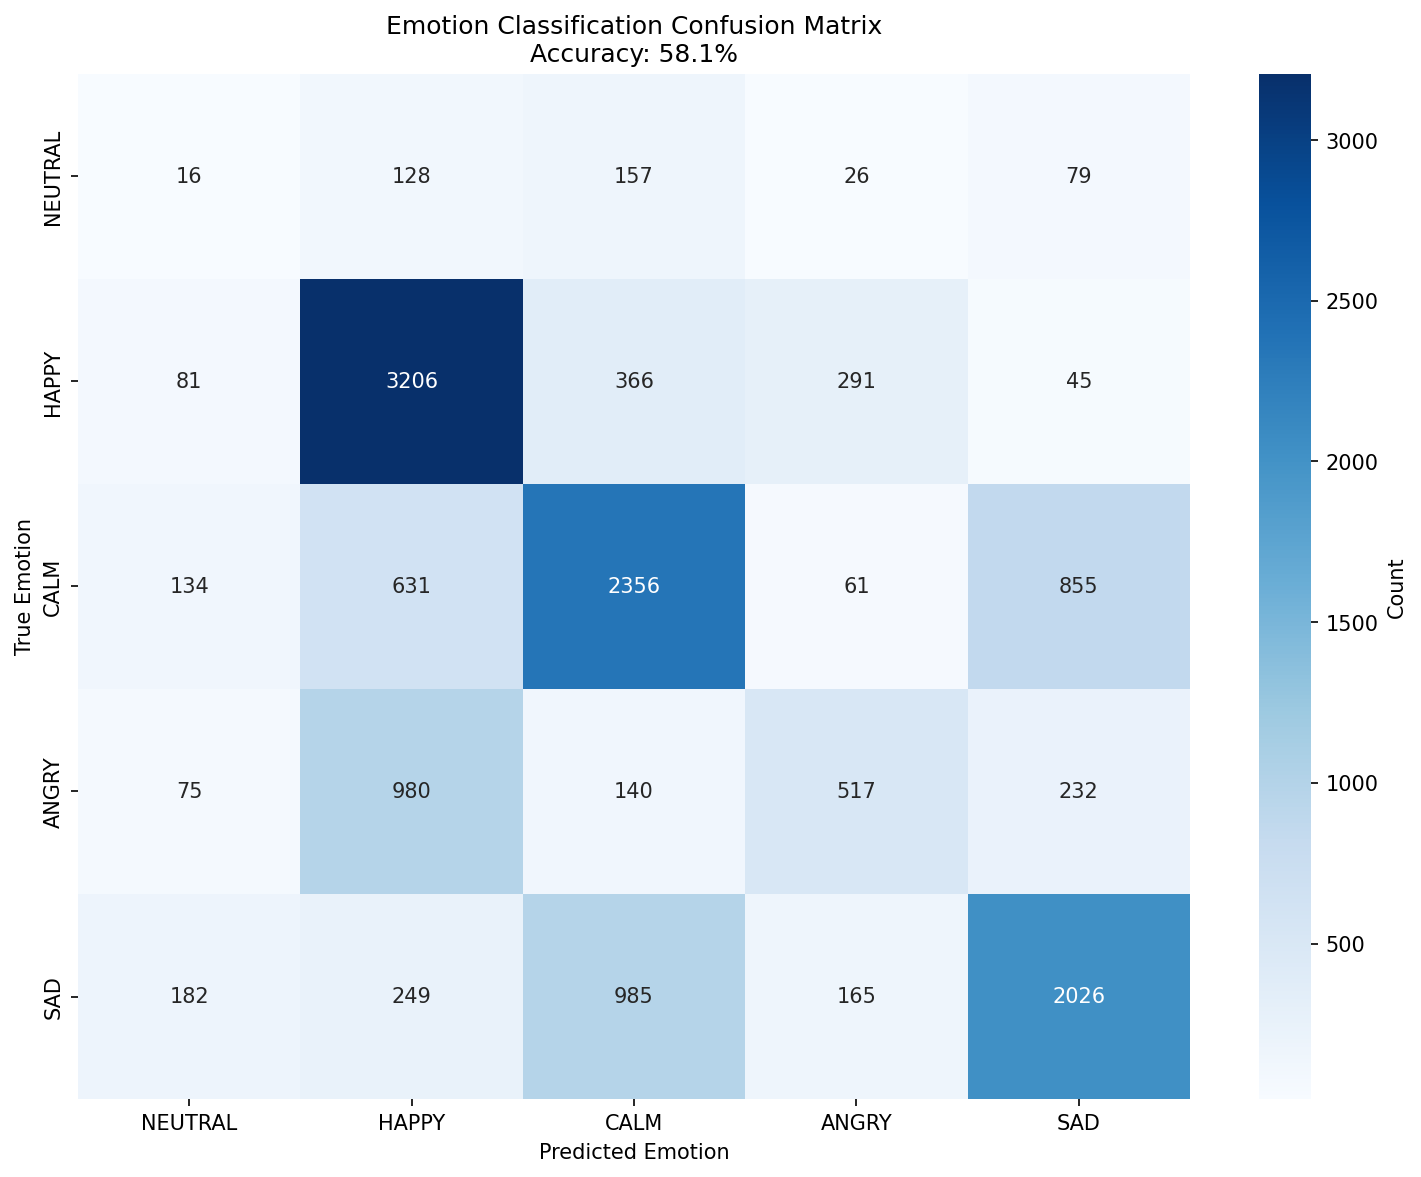


Displaying Valence-Arousal Scatter Plot:


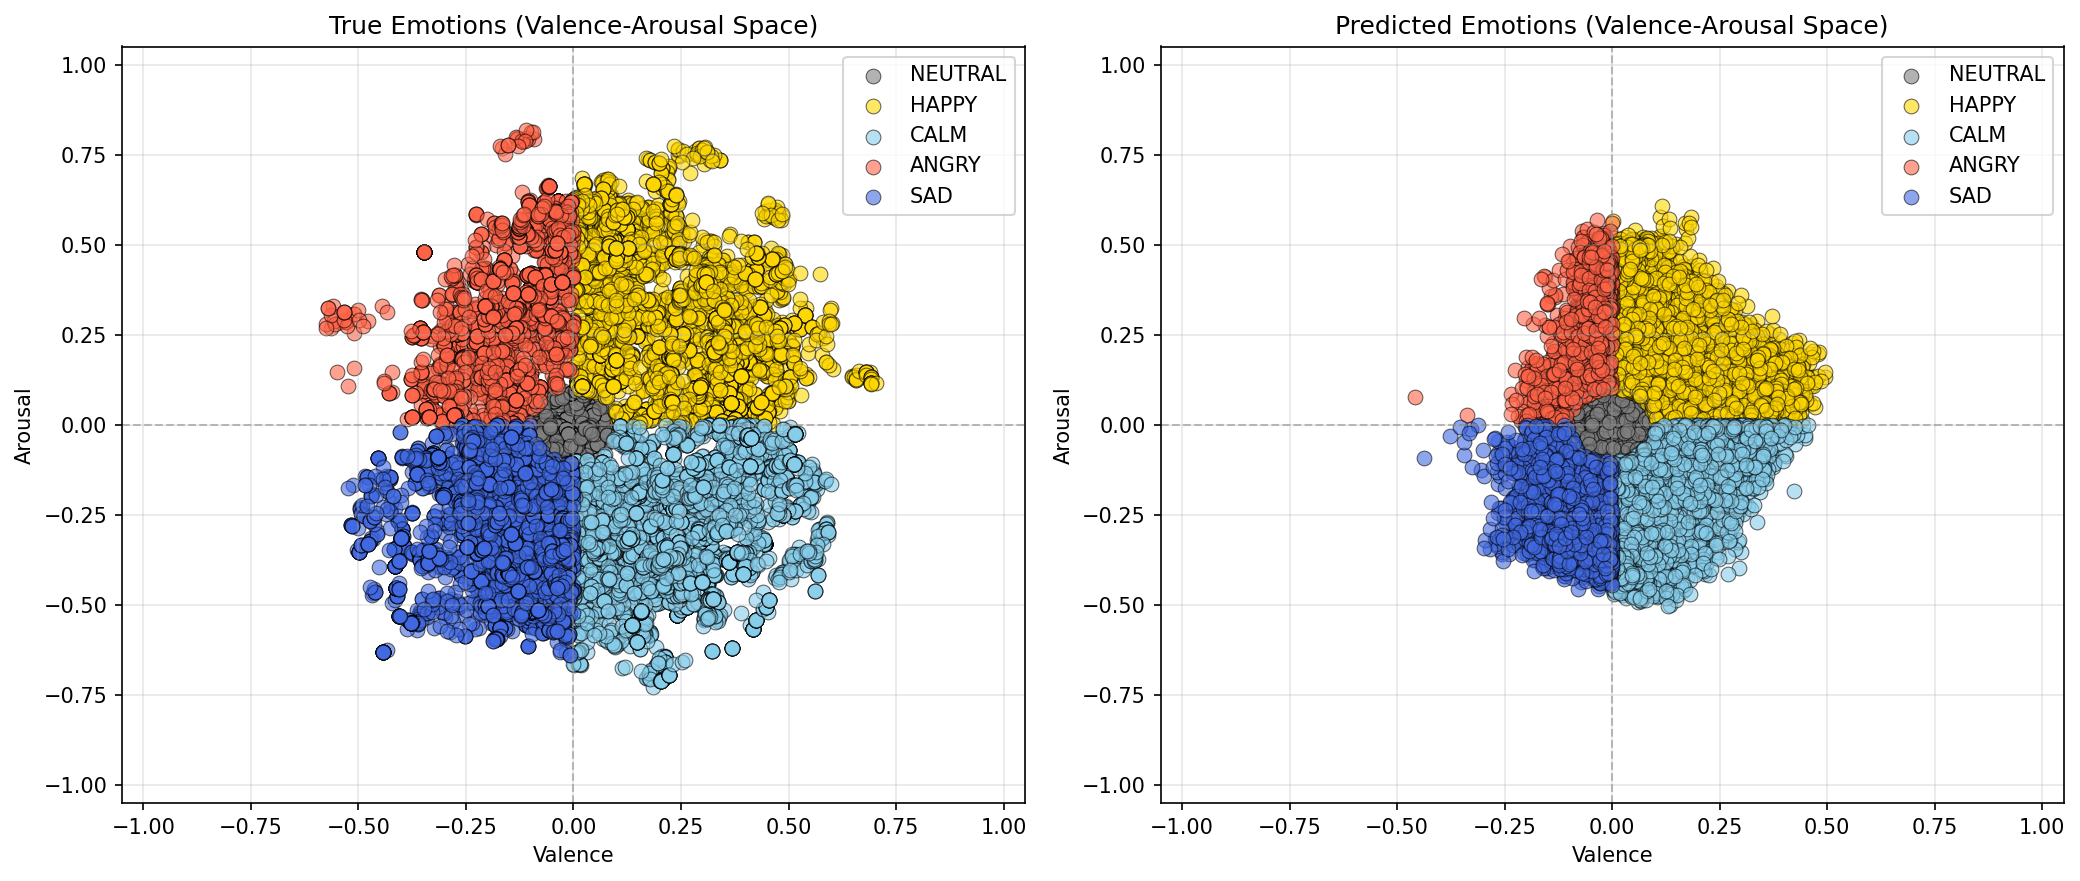


Displaying True vs Predicted Emotion Distributions:


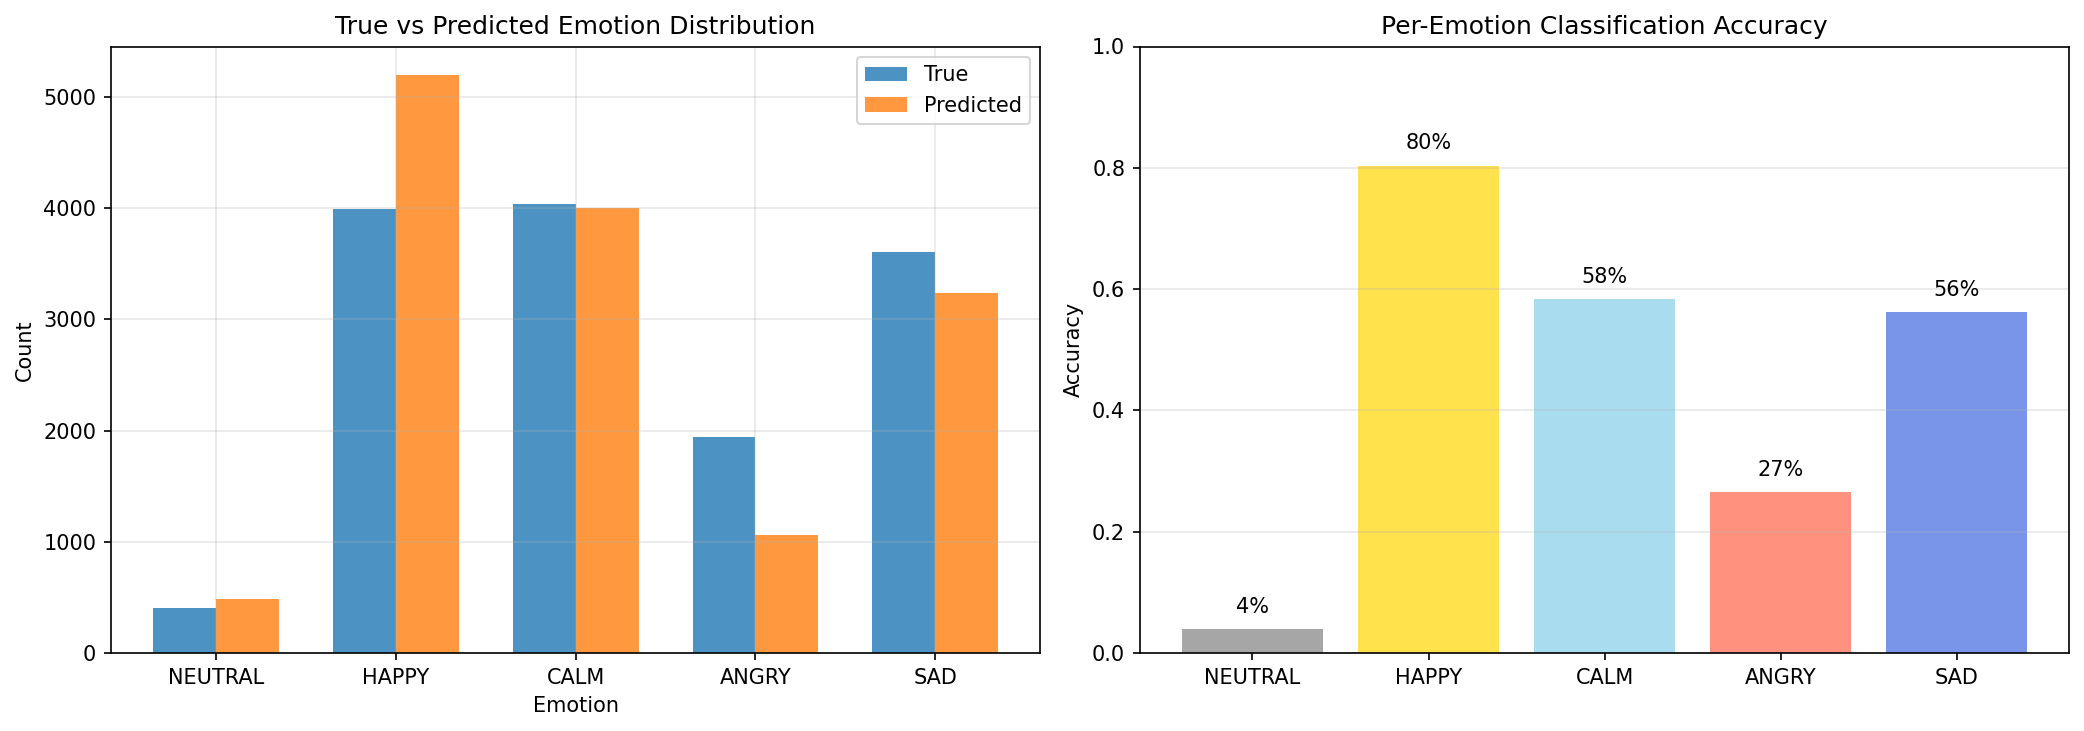

In [7]:
from IPython.display import Image, display

print("Displaying Emotion Classification Confusion Matrix:")
display(Image(filename='emotion_cm_cnn.png'))

print("\nDisplaying Valence-Arousal Scatter Plot:")
display(Image(filename='emotion_scatter_cnn.png'))

print("\nDisplaying True vs Predicted Emotion Distributions:")
display(Image(filename='emotion_dist_cnn.png'))

In [8]:
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_3 (Normalization) │ (None, 128, 128, 1)    │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,959 (398.29 KB)

 Trainable params: 101,506 (396.51 KB)

 Non-trainable params: 451 (1.77 KB)

 Optimizer params: 2 (12.00 B)